# Fine-tuning Stable Diffusion Model

## 1. Prepare Dataset - Kvasir

In [ ]:
import torch
import math
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
from torchvision import transforms
import os
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from tqdm.auto import tqdm
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import set_seed
import bitsandbytes as bnb
import torch.nn.functional as F
import logging, sys
import itertools


c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\models\transformers\transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.


In [2]:
class KvasirDataset(Dataset):
    def __init__(self,image_desc_file, image_data_root, tokenizer, img_size):
        # self.image_desc_file = image_desc_file
        self.image_data_root = image_data_root
        self.tokenizer = tokenizer
        self.image_size = img_size
        self.image_desc_data = pd.read_csv(image_desc_file)
        self.len = len(self.image_desc_data)
        self.transforms = transforms.Compose([
            transforms.Resize(self.image_size),
            transforms.CenterCrop(self.image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5],[0.5])
        ])
        
    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        row = self.image_desc_data.iloc[idx]
        image_path = os.path.join(self.image_data_root, row.iloc[0], row.iloc[1])
        image = Image.open(image_path).convert('RGB')
        # print(image.size)
        image = self.transforms(image)

        desc_tokens = self.tokenizer(row.iloc[2],
                                     padding='max_length',
                                     truncation=True,
                                     max_length=self.tokenizer.model_max_length,
                                     return_tensors='pt'
                                    )
        desc_ids = desc_tokens.input_ids.squeeze(0)
        return {'images': image, 'prompt_ids': desc_ids}

In [4]:
from huggingface_hub import login
login

<function huggingface_hub._login.login(token: Optional[str] = None, *, add_to_git_credential: bool = False, new_session: bool = True, write_permission: bool = False) -> None>

## Load Pretrained Model stabilityai/sd-turbo

In [3]:
image_desc_file = 'C:\COMP9800\Dataset\kvasir-dataset\image_description_partial.csv'
image_data_root = r'C:\COMP9800\Dataset\kvasir-dataset'

base_model_name = 'stabilityai/sd-turbo'

tokenizer = CLIPTokenizer.from_pretrained(
    base_model_name,
    subfolder="tokenizer",
)

vae = AutoencoderKL.from_pretrained(
    base_model_name, subfolder="vae"
)

text_encoder = CLIPTextModel.from_pretrained(
    base_model_name, subfolder="text_encoder"
)

unet = UNet2DConditionModel.from_pretrained(
    base_model_name, subfolder="unet"
)

noise_scheduler = DDPMScheduler.from_config(base_model_name, subfolder="scheduler")




c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\configuration_utils.py:245: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


## Hyperparameters

In [ ]:
device = 'cpu'
learning_rate = 0.00005
train_batch_size = 8
lr_scheduler_type = 'constant'
lr_warmup_steps=100
gradient_accumulation_steps = 2
max_train_steps = 1
train_text_encoder = False
train_batch_size = 2
output_dir='fine_tuned_models'
mixed_precision = 'fp16'
max_grad_norm = 1
save_steps = 500

In [5]:
def collate_fn(examples):
    input_ids = [example["prompt_ids"] for example in examples]
    pixel_values = [example["images"] for example in examples]

    pixel_values = torch.stack(pixel_values)
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()

    input_ids = tokenizer.pad(
        {"input_ids": input_ids},
        padding="max_length",
        return_tensors="pt",
        max_length=tokenizer.model_max_length
    ).input_ids

    batch = {
        "input_ids": input_ids,
        "pixel_values": pixel_values,
    }
    return batch

## Load Dataset

In [6]:
print('Sample Size in VAE:', vae.sample_size)

ds = KvasirDataset(image_desc_file, image_data_root, tokenizer, vae.sample_size)

# to_pil = transforms.ToPILImage()
# to_pil(ds[0]['images'])

train_dataloader = DataLoader(
    ds, batch_size=train_batch_size, shuffle=True, collate_fn=collate_fn
)

Sample Size in VAE: 768


C:\Users\50183\AppData\Local\Temp\ipykernel_24324\1858527567.py:1: FutureWarning: Accessing config attribute `sample_size` directly via 'AutoencoderKL' object attribute is deprecated. Please access 'sample_size' over 'AutoencoderKL's config object instead, e.g. 'unet.config.sample_size'.
  print('Sample Size in VAE:', vae.sample_size)
C:\Users\50183\AppData\Local\Temp\ipykernel_24324\1858527567.py:3: FutureWarning: Accessing config attribute `sample_size` directly via 'AutoencoderKL' object attribute is deprecated. Please access 'sample_size' over 'AutoencoderKL's config object instead, e.g. 'unet.config.sample_size'.
  ds = KvasirDataset(image_desc_file, image_data_root, tokenizer, vae.sample_size)


In [7]:
class EarlyStop:
    def __init__(self, max_iter):
        self.max_iteration = max_iter
        self.best_loss = None
        self.counter = 0
        self.need_stop = False
        self.loss_history=[]

    def step(self, val_loss):
        self.loss_history.append(val_loss)
        if self.best_loss is None:
            self.best_loss = val_loss
        elif self.best_loss > val_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.max_iteration:
                self.need_stop = True
        

In [8]:
# logger = get_logger(__name__)

# for h in logger.logger.handlers[:]:
#     logger.logger.removeHandler(h)

# handler = logging.StreamHandler(sys.stdout)
# handler.setLevel(logging.INFO)
# logger.logger.addHandler(handler)


In [ ]:
import torch.nn as nn

class MedQATTIModel(nn.Module):
    def __init__(self, vae, text_encoder, unet, noise_scheduler, weight_dtype, train_text_encoder):
        super().__init__()
        
        self.vae = vae
        self.text_encoder = text_encoder
        self.unet = unet
        self.noise_scheduler = noise_scheduler
        self.weight_dtype = weight_dtype
        
        self.vae.eval() #freeze
        if not train_text_encoder: 
            self.text_encoder.eval() #freeze
        else:
            self.text_encoder.gradient_checkpointing_enable()
        self.unet.enable_gradient_checkpointing()

    def forward(self, batch):
        latents = self.vae.encode(batch["pixel_values"].to(dtype=self.weight_dtype)).latent_dist.sample()
        latents = latents * 0.18215 #Normalize Latent for unet

        # Sample noise
        noise = torch.randn_like(latents)
        batch_size = latents.shape[0]
        # Sample a random timestep for each image
        timesteps = torch.randint(0, 
                                  self.noise_scheduler.config.num_train_timesteps, 
                                  (batch_size,), 
                                  device=latents.device)
        timesteps = timesteps.long()

        # Add noise to the latents, forward process of diffusion
        noisy_latents = self.noise_scheduler.add_noise(latents, noise, timesteps)

        # Get the text embedding for conditioning
        encoder_hidden_states = self.text_encoder(batch["input_ids"])[0]
        
        # Predict the noise residual
        noise_pred = self.unet(noisy_latents, timesteps, encoder_hidden_states).sample

        if self.noise_scheduler.config.prediction_type == "epsilon":
            target = noise
        elif self.noise_scheduler.config.prediction_type == "v_prediction":
            target = noise_scheduler.get_velocity(latents, noise, timesteps)
            
        return noise_pred , target

In [ ]:
def training_function(text_encoder, vae, unet, train_dataloader):
    loss_hist = []
    set_seed(27)
    accelerator = Accelerator(
        gradient_accumulation_steps=gradient_accumulation_steps,
        mixed_precision=mixed_precision,
    )
    print('Available Device:',accelerator.device)
    device = accelerator.device

    # Use 8-bit Adam for lower memory usage or to fine-tune the model in 16GB GPUs
    if device=='cuda':
        optimizer_class = bnb.optim.AdamW8bit
    else:
        optimizer_class = torch.optim.AdamW

    params_to_optimize = (
        itertools.chain(unet.parameters(), text_encoder.parameters()) if train_text_encoder else unet.parameters()
    )

    optimizer = optimizer_class(
        params_to_optimize,
        lr=learning_rate,
    )
    
    lr_scheduler = get_scheduler(
        lr_scheduler_type,
        optimizer=optimizer,
        num_warmup_steps=lr_warmup_steps * gradient_accumulation_steps,
        num_training_steps=max_train_steps * gradient_accumulation_steps,
    )

    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    # We need to recalculate our total training steps as the size of the training dataloader may have changed.
    num_update_steps_per_epoch = math.ceil(len(train_dataloader) / gradient_accumulation_steps)
    num_train_epochs = math.ceil(max_train_steps / num_update_steps_per_epoch)
    
    total_batch_size = train_batch_size * accelerator.num_processes * gradient_accumulation_steps
    
    print("total btach size:",total_batch_size)
    print("***** Running training *****")
    print(f"  Num examples = {len(ds)}")
    print(f"  Instantaneous batch size per device = {train_batch_size}")
    print(f"  Total train batch size (w. parallel, distributed & accumulation) = {total_batch_size}")
    print(f"  Gradient Accumulation steps = {gradient_accumulation_steps}")
    print(f"  Total optimization steps = {max_train_steps}")
    # Only show the progress bar once on each machine.
    progress_bar = tqdm(range(max_train_steps), disable=not accelerator.is_local_main_process)
    progress_bar.set_description("Steps")

    global_step = 0

    early_stopping = EarlyStop(max_iter=10000)

    model = MedQATTIModel(vae, text_encoder, unet, 
                          noise_scheduler, weight_dtype, 
                          train_text_encoder)
    
    model.to(accelerator.device, dtype=weight_dtype)

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(model, 
                                                                           optimizer, 
                                                                           train_dataloader, 
                                                                           lr_scheduler)
    for epoch in range(num_train_epochs):
        model.train()
        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate(unet):
                noise_pred, target = model(batch)
                loss = F.mse_loss(noise_pred.float(), target.float(), reduction="mean")
                accelerator.backward(loss)
                early_stopping.step(loss)
                if early_stopping.need_stop:
                    print("Early stopping triggered")
                    break

                if accelerator.sync_gradients:
                    params_to_clip = (
                        itertools.chain(unet.parameters(), text_encoder.parameters())
                        if train_text_encoder
                        else unet.parameters()
                    )
                    accelerator.clip_grad_norm_(params_to_clip, max_grad_norm)
                optimizer.step()
                optimizer.zero_grad()

            # Checks if the accelerator has performed an optimization step behind the scenes
            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                if global_step % save_steps == 0:
                    if accelerator.is_main_process:
                        unwrapped_unet = accelerator.unwrap_model(model.unet)
                        save_path = os.path.join(output_dir, f"checkpoint-{global_step}.pt")
                        accelerator.save(unwrapped_unet.state_dict(), save_path)

            logs = {"loss": loss.detach().item()}
            loss_hist.append(logs['loss'])
            progress_bar.set_postfix(**logs)

            if global_step >= max_train_steps:
                break
        accelerator.wait_for_everyone()

    # Create the pipeline using using the trained modules and save it.
    if accelerator.is_main_process:
        unwrapped_unet = accelerator.unwrap_model(model.unet)
        save_path = os.path.join(output_dir, f"checkpoint-{global_step}.pt")
        accelerator.save(unwrapped_unet.state_dict(), save_path)
    
    return loss_hist

In [ ]:
loss_hist = training_function(text_encoder, vae, unet, train_dataloader)

Available Device: cpu
total btach size: 4
***** Running training *****
  Num examples = 400
  Instantaneous batch size per device = 2
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 2
  Total optimization steps = 1500


Steps:   0%|          | 0/1500 [00:00<?, ?it/s]

In [ ]:
# Free up some memory after training
for param in itertools.chain(unet.parameters(), text_encoder.parameters()):
    if param.grad is not None:
        del param.grad  # Free some memory
    torch.cuda.empty_cache()  # Empty the CUDA cache

Launching training on one GPU.


/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


total btach size: 4
***** Running training *****
  Num examples = 400
  Instantaneous batch size per device = 2
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 2
  Total optimization steps = 1500


  0%|          | 0/1500 [00:00<?, ?it/s]

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


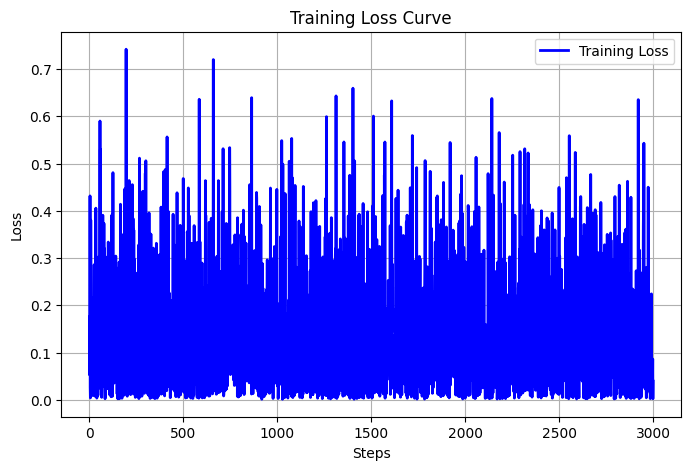

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_hist, label="Training Loss", color="blue", linewidth=2)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)

plt.savefig('loss_curver.png', dpi=600)

plt.show()

## Evaluate

In [6]:
import torch
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained(r'C:\Users\50183\Downloads\results (5)\fine_tuned_models\checkpoint-1000', torch_dtype=torch.float32)
pipe = pipe.to(device)

c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\models\vq_model.py:20: FutureWarning: `VQEncoderOutput` is deprecated and will be removed in version 0.31. Importing `VQEncoderOutput` from `diffusers.models.vq_model` is deprecated and this will be removed in a future version. Please use `from diffusers.models.autoencoders.vq_model import VQEncoderOutput`, instead.
  deprecate("VQEncoderOutput", "0.31", deprecation_message)
c:\Users\50183\.conda\envs\env_tti\Lib\site-packages\diffusers\models\vq_model.py:25: FutureWarning: `VQModel` is deprecated and will be removed in version 0.31. Importing `VQModel` from `diffusers.models.vq_model` is deprecated and this will be removed in a future version. Please use `from diffusers.models.autoencoders.vq_model import VQModel`, instead.
  deprecate("VQModel", "0.31", deprecation_message)
Loading pipeline components...: 100%|██████████| 5/5 [00:02<00:00,  2.32it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.sta

100%|██████████| 30/30 [04:59<00:00,  9.98s/it]


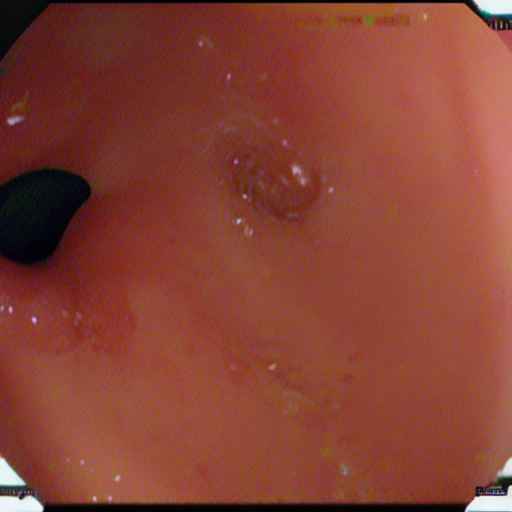

In [16]:
# prompt='an endoscopic image of dyed resection margins shows a close - up view of a surgical site within the gastrointestinal tract, likely the stomach or duodenum. the resection margins are dyed in a specific color, which appears to be a shade of blue.'
prompt='An endoscopic image of polyps typically shows the polyps on the mucosa of the gastrointestinal tract. The polyps appears as small, reddish-brown or yellowish-brown growths. ' \
'The surrounding mucosa is a lighter shade of red, and the surface texture of the polyps can be slightly rough.'
with torch.no_grad():
    image = pipe(
        prompt,
        negative_prompt="",
        num_inference_steps=30,
        guidance_scale=7.0,
    ).images[0]
image

In [15]:
# dataloader = DataLoader(ds, batch_size=8, shuffle=True)
# pipe.unet.train()
# optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=training_args["learning_rate"])
# criterion = torch.nn.MSELoss()
# for epoch in range(training_args["num_train_epochs"]):
#     print(f"Epoch {epoch + 1}/{training_args['num_train_epochs']}")
#     for batch in tqdm(dataloader):
#         images = batch[0].to(device)
#         noise = torch.randn_like(images).to(device)

#         # Forward pass
#         outputs = pipe.unet(images, noise)
#         loss = criterion(outputs, images)

#         # Backward pass and optimization
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         print(f"Loss: {loss.item()}")

In [16]:
# pipe.unet()